# Fitting an MDM model

This notebook fits an MDM model on a small bundled multivariate time series
and plots the learned DAG. Structure learning uses hill-climbing (`method="hc"`).
The filtering and smoothing stages produce time-varying parameters for each node.

In [1]:
import sys

from pathlib import Path as _Path
_root = _Path.cwd()
if (_root / "retail_helpers.py").exists():
    # Running from examples/notebooks → package root is ../..
    sys.path.append(str((_root / "../..").resolve()))
else:
    sys.path.append(str((_root / "..").resolve()))
import pandas as pd

from mdmp import MDM, list_datasets, load_dataset, plot_arcs, plot_dag


d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
list_datasets()

['mdmr_test_data', 'covid_regional_timeseries']

In [3]:
data = load_dataset("covid_regional_timeseries")

# Fit MDM model
model = MDM(data, method="hc", verbose=True)


Learning structure using method: hc


  0%|          | 5/1000000 [00:01<86:57:02,  3.19it/s] 


Selecting discount factors...


Selecting discount factors: 255it [00:00, 295.94it/s]


Computing filtered estimates...


Filtering nodes: 5it [00:00, 209.56it/s]


Computing smoothed estimates...


Smoothing nodes: 5it [00:00, 240.89it/s]


MDM processing completed in 8.30 seconds


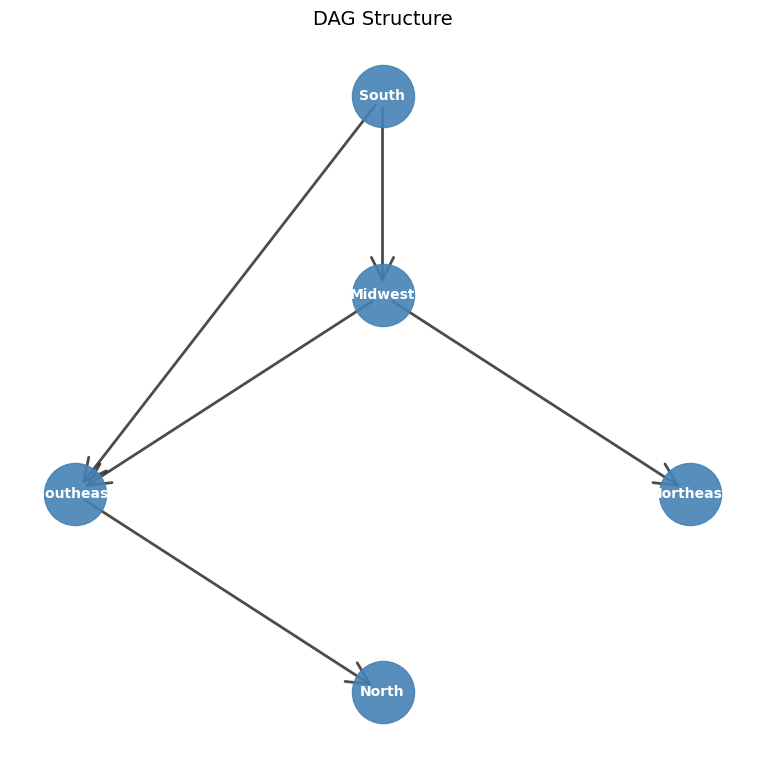

In [5]:
# Plot the learned DAG
plot_dag(model, plot_type="graph");

## Compare HC vs NOTEARS

Run both structure learning methods and compare:
- Computation time
- Number of edges
- Learned DAG structure

In [6]:
import time

# HC
t0 = time.perf_counter()
model_hc = MDM(data, method="hc", nbf=15, verbose=False)
time_hc = time.perf_counter() - t0

# NOTEARS
t0 = time.perf_counter()
model_notears = MDM(data, method="notears", nbf=15, verbose=False)
time_notears = time.perf_counter() - t0

# Comparison table
comparison = pd.DataFrame({
    "Method": ["HC", "NOTEARS"],
    "Time (s)": [time_hc, time_notears],
    "Num edges": [int(model_hc.adj_mat.sum()), int(model_notears.adj_mat.sum())],
})
print(comparison.to_string(index=False))

  0%|          | 5/1000000 [00:01<83:56:34,  3.31it/s] 


 Method  Time (s)  Num edges
     HC  2.374654          5
NOTEARS  1.502702          7


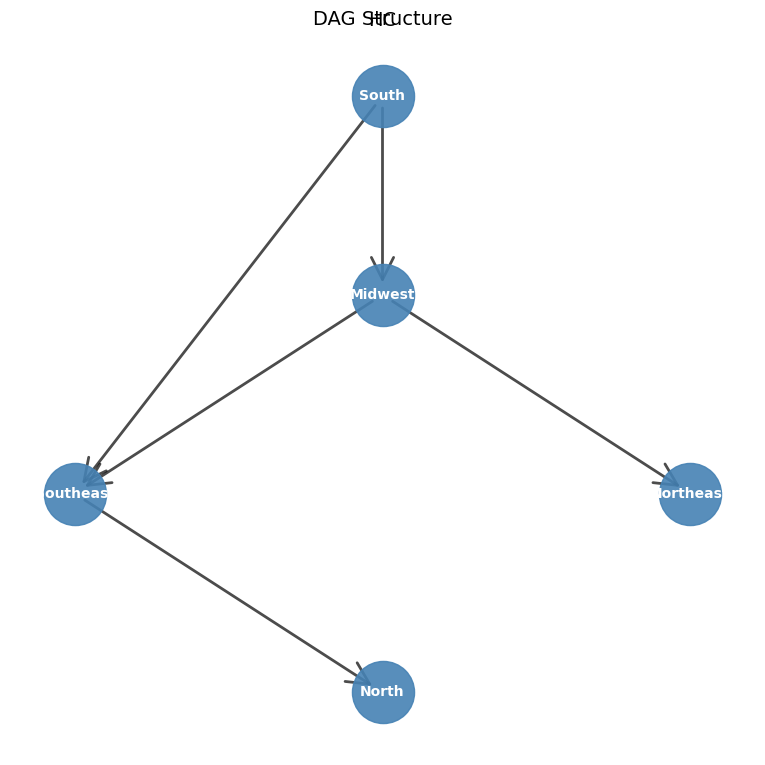

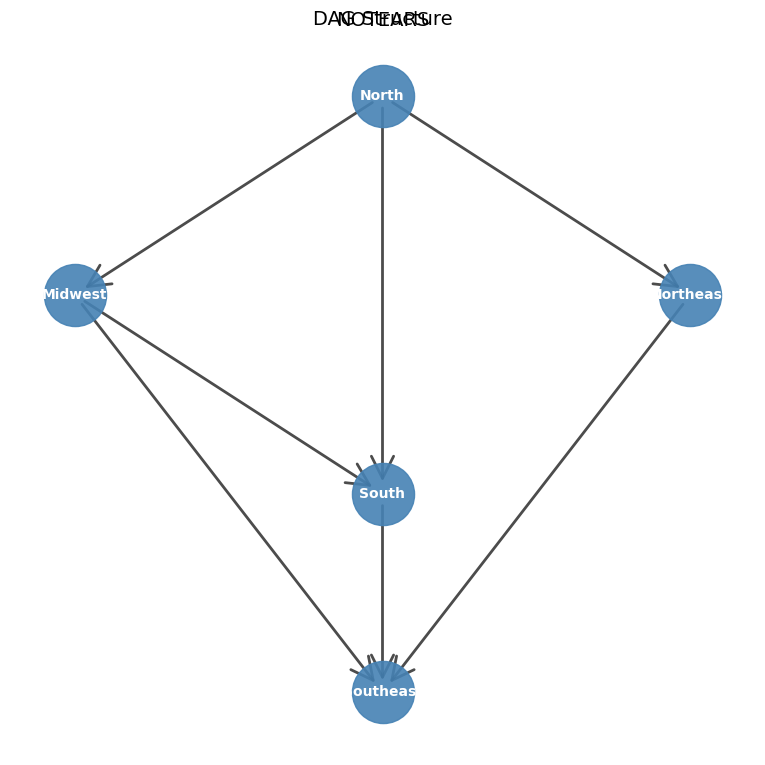

In [7]:
# Side-by-side DAG plots (plot_dag creates its own figure for each)
import matplotlib.pyplot as plt

fig1 = plot_dag(model_hc, plot_type="graph", layout_seed=5)
fig1.suptitle("HC", fontsize=14)
plt.show()

fig2 = plot_dag(model_notears, plot_type="graph", layout_seed=5)
fig2.suptitle("NOTEARS", fontsize=14)
plt.show()

In [8]:
# Adjacency matrices comparison
labels = model_hc.node_names if model_hc.node_names else [f"V{i+1}" for i in range(model_hc.adj_mat.shape[0])]
print("HC adjacency:")
print(pd.DataFrame(model_hc.adj_mat, index=labels, columns=labels))
print("\nNOTEARS adjacency:")
print(pd.DataFrame(model_notears.adj_mat, index=labels, columns=labels))

HC adjacency:
           Southeast  Midwest  Northeast  North  South
Southeast          0        0          0      1      0
Midwest            1        0          1      0      0
Northeast          0        0          0      0      0
North              0        0          0      0      0
South              1        1          0      0      0

NOTEARS adjacency:
           Southeast  Midwest  Northeast  North  South
Southeast          0        0          0      0      0
Midwest            1        0          0      0      1
Northeast          1        0          0      0      0
North              0        1          1      0      1
South              1        0          0      0      0


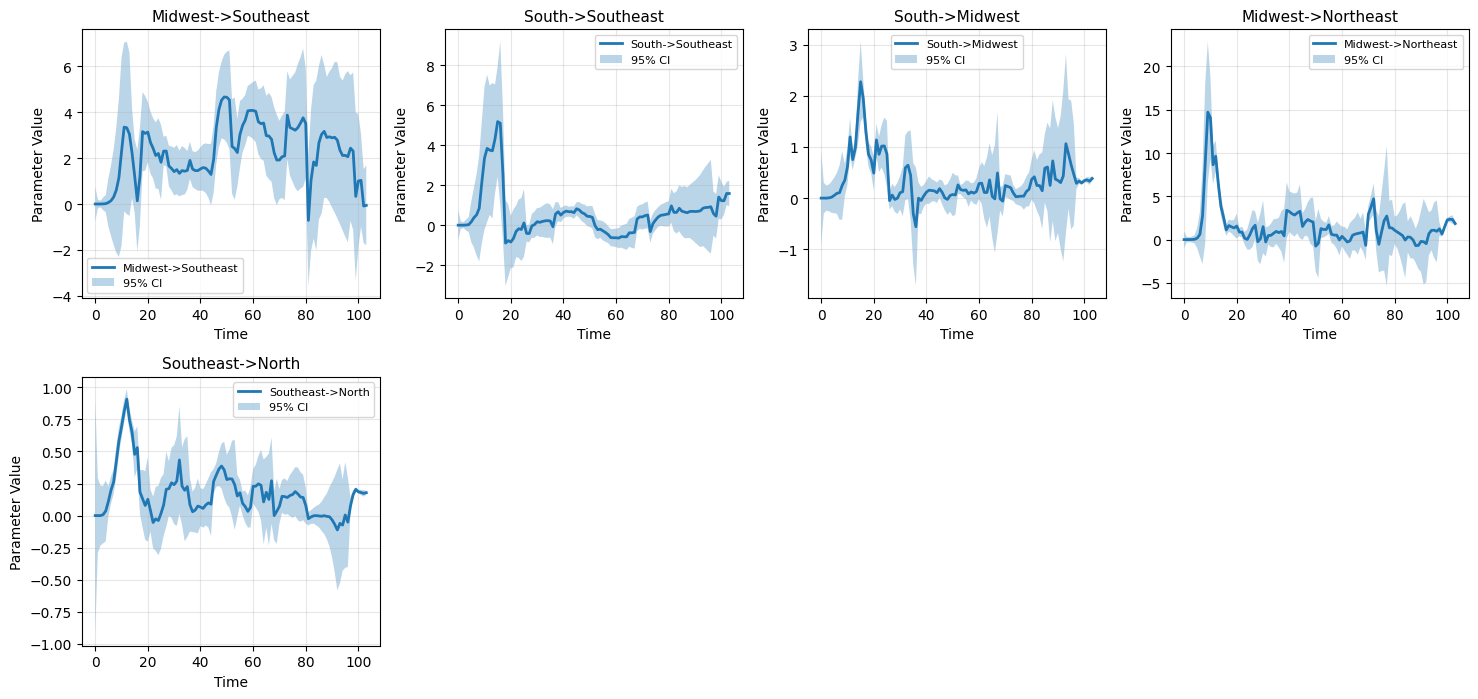

In [9]:
plot_arcs(model, plot_type="connections");

In [16]:
model.adj_mat

array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]])